
# 맥락 정리

이 분석의 주인은 누구인가? :  CRM/로열티 마케팅 담당 데이터 애널리스트

이 분석으로 바뀌는 의사결정은 무엇인가?

- 단순히 “많이 팔렸다”가 아니라,
    - 어떤 고객이 반응했는지
    - 어떤 채널이 효과적이었는지
    - 어떤 오퍼가 실제 매출로 이어졌는지
    - 캠페인 이후 구매가 얼마나 발생했는지를 모두 확인 필요

핵심 KPI는 무엇인가?

- 유효 구매 전환율

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json 

portfolio = pd.read_csv('C:/Users/Team_17/Data/portfolio.csv')
profile = pd.read_csv('C:/Users/Team_17/Data/profile.csv')
menu = pd.read_csv('C:/Users/Team_17/Data/starbucks_menu_260112.csv')
transcript = pd.read_csv('C:/Users/Team_17/Data/transcript.csv')


print(f"Portfolio: {portfolio.shape}")
print(f"Profile: {profile.shape}")
print(f"Transcript: {transcript.shape}")
print(f"Menu: {menu.shape}")

Portfolio: (10, 7)
Profile: (17000, 6)
Transcript: (306534, 5)
Menu: (195, 13)


# 1.Portfolio 테이블 : 프로모션 자체의 속성 테이블

쿠폰 10종 세트 설명서 

프로모션 종류 10개

##### 한눈에 보기

In [40]:
print("--- 1. Shape (행, 열) ---")
print(portfolio.shape)

print("\n--- 2. Info (데이터 타입 및 Non-Null 개수) ---")
portfolio.info()

print("\n--- 3. 결측치 개수 ---")
print(portfolio.isnull().sum())

print("\n--- 4. 데이터 생김새 (Head 3줄) ---")
display(portfolio.head(3))

--- 1. Shape (행, 열) ---
(10, 7)

--- 2. Info (데이터 타입 및 Non-Null 개수) ---
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  10 non-null     int64
 1   reward      10 non-null     int64
 2   channels    10 non-null     str  
 3   difficulty  10 non-null     int64
 4   duration    10 non-null     int64
 5   offer_type  10 non-null     str  
 6   id          10 non-null     str  
dtypes: int64(4), str(3)
memory usage: 692.0 bytes

--- 3. 결측치 개수 ---
Unnamed: 0    0
reward        0
channels      0
difficulty    0
duration      0
offer_type    0
id            0
dtype: int64

--- 4. 데이터 생김새 (Head 3줄) ---


,Unnamed: 0,reward,channels,difficulty,duration,offer_type,id
0,0,10,"['email', 'mobile', 'social']",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,1,10,"['web', 'email', 'mobile', 'social']",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,2,0,"['web', 'email', 'mobile']",0,4,informational,3f207df678b143eea3cee63160fa8bed


In [21]:
portfolio.head(5)

,Unnamed: 0,reward,channels,difficulty,duration,offer_type,id
0,0,10,"['email', 'mobile', 'social']",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,1,10,"['web', 'email', 'mobile', 'social']",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,2,0,"['web', 'email', 'mobile']",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,3,5,"['web', 'email', 'mobile']",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,4,5,"['web', 'email']",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7


In [22]:
portfolio.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  10 non-null     int64
 1   reward      10 non-null     int64
 2   channels    10 non-null     str  
 3   difficulty  10 non-null     int64
 4   duration    10 non-null     int64
 5   offer_type  10 non-null     str  
 6   id          10 non-null     str  
dtypes: int64(4), str(3)
memory usage: 692.0 bytes


In [23]:
portfolio["offer_type"].value_counts()

offer_type
bogo             4
discount         4
informational    2
Name: count, dtype: int64

결측치, 중복 없음

In [24]:
portfolio.isnull().sum()

Unnamed: 0    0
reward        0
channels      0
difficulty    0
duration      0
offer_type    0
id            0
dtype: int64

In [42]:
print(portfolio.duplicated().sum())

0


### portfolio 1차 EDA

1. 오퍼 타입별 평균 보상(reward)과 최소 지출 금액(difficulty) 비교

In [47]:
display(portfolio.groupby('offer_type')[['reward', 'difficulty']].mean())

,reward,difficulty
offer_type,,
bogo,7.5,7.50
discount,3.0,11.75
informational,0.0,0.00


2. 최소 지출 금액(difficulty) 대비 보상(reward) 비율 파악 (어떤 게 가성비가 좋을까?)

(informational은 보상과 리워드 0이기 때문에 제외)


In [49]:
portfolio_check = portfolio[portfolio['offer_type'] != 'informational'].copy()
portfolio_check['가성비'] = portfolio_check['reward'] / portfolio_check['difficulty']

print("BOGO vs Discount 가성비 비교")
display(portfolio_check[['offer_type', 'difficulty', 'reward', '가성비']].sort_values('가성비', ascending=False))

BOGO vs Discount 가성비 비교


,offer_type,difficulty,reward,가성비
0,bogo,10,10,1.000000
1,bogo,10,10,1.000000
3,bogo,5,5,1.000000
8,bogo,5,5,1.000000
5,discount,7,3,0.428571
4,discount,20,5,0.250000
6,discount,10,2,0.200000
9,discount,10,2,0.200000


3. 숫자형 분포, 평균/중앙값 차이, 이상치 (reward, difficulty, duration)

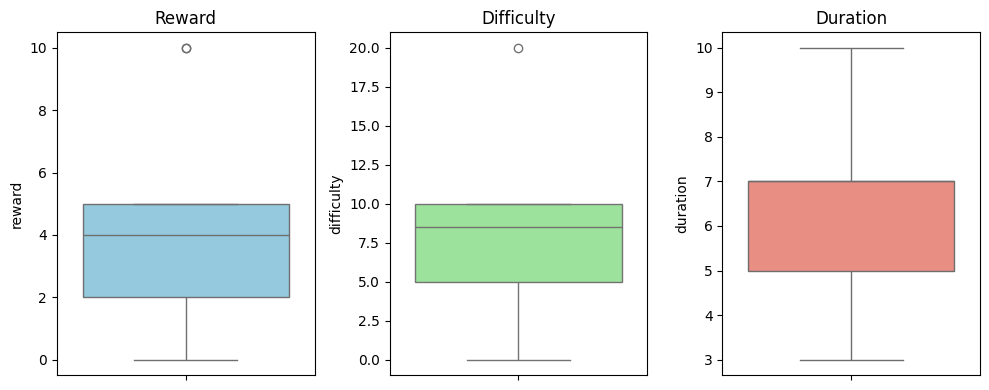

In [51]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
sns.boxplot(y=portfolio['reward'], color='skyblue')
plt.title('Reward')

plt.subplot(1, 3, 2)
sns.boxplot(y=portfolio['difficulty'], color='lightgreen')
plt.title('Difficulty')

plt.subplot(1, 3, 3)
sns.boxplot(y=portfolio['duration'], color='salmon')
plt.title('Duration')
plt.tight_layout()
plt.show()

4. 범주형 (channels)

아직 str

In [54]:
print(portfolio['channels'].value_counts())

channels
['web', 'email', 'mobile', 'social']    4
['web', 'email', 'mobile']              3
['email', 'mobile', 'social']           2
['web', 'email']                        1
Name: count, dtype: int64


5. 세그먼트 비교 offer_type 별 수치형 변수 평균 비교

In [57]:
print(portfolio.groupby('offer_type')[['reward', 'difficulty', 'duration']].mean())

               reward  difficulty  duration
offer_type                                 
bogo              7.5        7.50       6.0
discount          3.0       11.75       8.5
informational     0.0        0.00       3.5


In [58]:
print(portfolio.groupby('offer_type')[['reward', 'difficulty', 'duration']].var())

                 reward  difficulty  duration
offer_type                                   
bogo           8.333333    8.333333  1.333333
discount       2.000000   32.250000  3.000000
informational  0.000000    0.000000  0.500000


### 확인 결과

1. BOGO는 고객이 7.5달러를 쓰면 7.5달러의 큰 보상을 주는 대신 유효기한을 짧게 쓰는 전략

2. Discount는 고객이 평균 11.75달러라는 큰 돈을 지불해야 3달러를 깎아줌. 대신, 유효기한을 평균 8.5일로 넉넉하게 줘서 여러번 채우라고 유도하는 전략

3. bogo는 난이도만큼 보상이 따르고 discount는 bogo만큼 가성비가 높지는 않음

4. informational은 전부 0. 그냥 홍보용 띄워놓는 용도

5. 10개의 오퍼 모두에 email이 포함되어 있음, 10개 중 9개에 mobile 알람 포함

['web','email'] 조합이 1건으로 유일하게 모바일 알림이 안 가는 쿠폰

6. reward 박스플롯에서 보상을 10달러나 주는 오퍼가 존재함

7. 20 달러나 써야하는 높은 난이도의 쿠폰 존재

**어떤 채널이 포함된 오퍼가 조회수나 전환률이 높을까?** 

**모바일 알람이 안 가는 1개의 오퍼는 고객들의 viewed 비율이 낮지 않을까?**

궁금해짐

### 전처리 필요

1. 불필요한 인덱스 Unnamed: 0 지우기
2. id 나중에 합쳐주기 위해 통일하기
3. channels의 데이터 타입이 str이므로 이후에 전처리 필요
4. duration 단위는 일, 고객이 오퍼 받은 이후 미션을 완료할 수 있는 기한, 이후에 다른 테이블 컬럼과 단위 맞추기

# 2. profile : 고객 프로필 테이블

고객정보, 성별, 나이, 수입 등 고객이 입력한 자신의 프로필

##### 한눈에 보기

In [61]:
print("--- 1. Shape ---")
print(profile.shape)

print("\n--- 2. Info ---")
profile.info()

print("\n--- 3. 결측치 수 ---")
print(profile.isnull().sum())

--- 1. Shape ---
(17000, 6)

--- 2. Info ---
<class 'pandas.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        17000 non-null  int64  
 1   gender            14825 non-null  str    
 2   age               17000 non-null  int64  
 3   id                17000 non-null  str    
 4   became_member_on  17000 non-null  int64  
 5   income            14825 non-null  float64
dtypes: float64(1), int64(3), str(2)
memory usage: 797.0 KB

--- 3. 결측치 수 ---
Unnamed: 0             0
gender              2175
age                    0
id                     0
became_member_on       0
income              2175
dtype: int64


In [25]:
profile.head()

,Unnamed: 0,gender,age,id,became_member_on,income
0,0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN


In [26]:
profile.info()

<class 'pandas.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        17000 non-null  int64  
 1   gender            14825 non-null  str    
 2   age               17000 non-null  int64  
 3   id                17000 non-null  str    
 4   became_member_on  17000 non-null  int64  
 5   income            14825 non-null  float64
dtypes: float64(1), int64(3), str(2)
memory usage: 797.0 KB


결측치, 중복 확인

In [27]:
profile.isnull().sum()

Unnamed: 0             0
gender              2175
age                    0
id                     0
became_member_on       0
income              2175
dtype: int64

In [62]:
print(portfolio.duplicated().sum())

0


### profile 1차 EDA

1. 118세 고객의 결측치 현황

In [65]:
ghost_users = profile[profile['age'] == 118]
print(f"나이가 118세인 고객 수: {len(ghost_users)}명")
print(ghost_users.isnull().sum())

나이가 118세인 고객 수: 2175명
Unnamed: 0             0
gender              2175
age                    0
id                     0
became_member_on       0
income              2175
dtype: int64


2. 숫자형 : 나이와 소득 분포 시각화

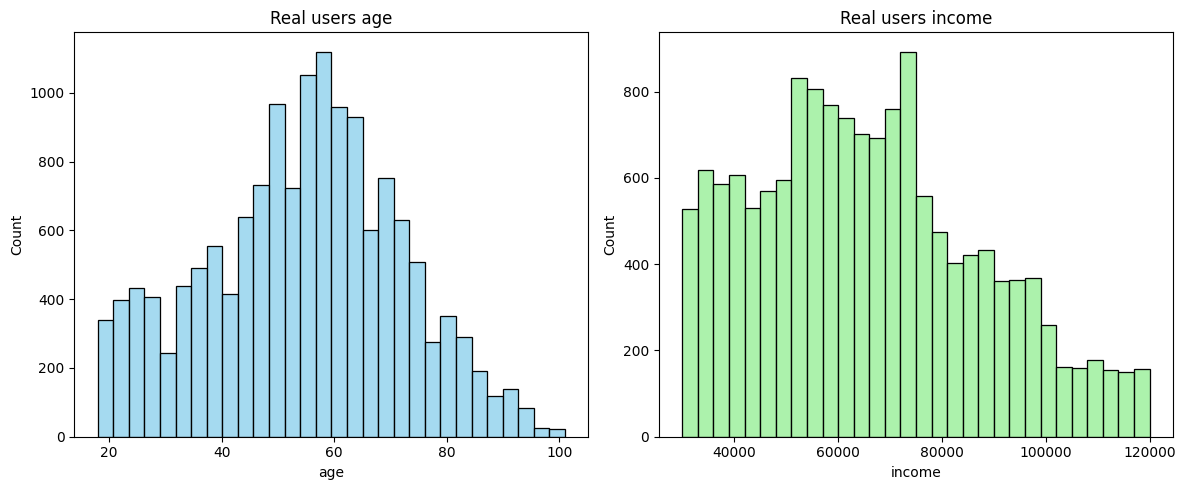

In [69]:
real_users = profile[profile['age'] != 118]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(real_users['age'], bins=30, color='skyblue')
plt.title('Real users age')

plt.subplot(1, 2, 2)
sns.histplot(real_users['income'], bins=30, color='lightgreen')
plt.title('Real users income')
plt.tight_layout()
plt.show()

3. 범주형 : 성별 분포

In [70]:
print(real_users['gender'].value_counts(normalize=True) * 100)

gender
M    57.227656
F    41.342327
O     1.430017
Name: proportion, dtype: float64


4. 가입일 데이터

데이터타입 변환 필요

In [71]:
print(profile['became_member_on'].head(3))

0    20170212
1    20170715
2    20180712
Name: became_member_on, dtype: int64


### 확인 결과

1. 나이가 118세인 고객수 확인 결과 2175명, 결측치 2175개와 유령 고객 모두 일치 (시스템 오류로 정보 누락이 아님)

-> 앱 가입할 때 정보 입력을 스킵한 고객군이기 때문에 정보 미제공 고객 unknown으로 따로 묶어야 할듯 (별도 그룹화)

2. 실제 고객의 나이 분포 결과 : 50 중반 ~ 60 초반에서 가장 높음

**핵심 고객이 중장년층이라는 것을 알 수 있음, 복잡한 미션보다는 직관적이고 쓰기 편한 오퍼가 더 잘 통하겠다는 가설**

3. 실제 고객의 수입 분포 결과 : 우측 꼬리 분포 

-> 고소득자로 갈 수록 인원수가 줄어듦, 몇 달러 할인 받자고 미션 수행을 할까?

**소득 구간 별로 쿠폰 완료율을 보는 것도 좋을 듯**

4. 성별 비율이 남성이 더 많은 것 확인 (과한 일반화는 주의)

5. 날짜 컬럼을 기준으로 신규 고객 / 기존 고객 나누기 가능


### 전처리 필요

1. gender도 2175명, income도 결측치가 2175명 -> 성별을 입력하지 않은 사람이 소득도 입력 안하나? -> 맞음

2. 성별과 수입은 NaN이지만 age는 결측치가 0 -> 118 이상치 확인 -> 1의 사람과 일치 -> unknown 묶기

3. became_member_on은 int64로 되어있음. 타입변환 필요

4. Unnamed : 0 날리고, id 통일 필요

# Transcript : 고객 행동 로그 테이블

스타벅스 앱 안에서 고객들이 결제한 기록이 담긴 행동 로그 데이터

##### 한눈에 보기

In [74]:
print("--- 1. Shape ---")
print(transcript.shape)

print("\n--- 2. Info ---")
transcript.info()

print("\n--- 3. 결측치 수 ---")
print(transcript.isnull().sum())

--- 1. Shape ---
(306534, 5)

--- 2. Info ---
<class 'pandas.DataFrame'>
RangeIndex: 306534 entries, 0 to 306533
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Unnamed: 0  306534 non-null  int64
 1   person      306534 non-null  str  
 2   event       306534 non-null  str  
 3   value       306534 non-null  str  
 4   time        306534 non-null  int64
dtypes: int64(2), str(3)
memory usage: 11.7 MB

--- 3. 결측치 수 ---
Unnamed: 0    0
person        0
event         0
value         0
time          0
dtype: int64


In [28]:
transcript.head()

,Unnamed: 0,person,event,value,time
0,0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0


In [29]:
transcript.info()

<class 'pandas.DataFrame'>
RangeIndex: 306534 entries, 0 to 306533
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Unnamed: 0  306534 non-null  int64
 1   person      306534 non-null  str  
 2   event       306534 non-null  str  
 3   value       306534 non-null  str  
 4   time        306534 non-null  int64
dtypes: int64(2), str(3)
memory usage: 11.7 MB


In [31]:
#offer_id가 있고 amount있음
transcript['value'].value_counts()

value
{'offer id': '2298d6c36e964ae4a3e7e9706d1fb8c2'}    14983
{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'}    14924
{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'}    14891
{'offer id': 'f19421c1d4aa40978ebb69ca19b0e20d'}    14835
{'offer id': 'ae264e3637204a6fb9bb56bc8210ddfd'}    14374
                                                    ...  
{'amount': 290.93}                                      1
{'amount': 43.91}                                       1
{'amount': 685.07}                                      1
{'amount': 405.04}                                      1
{'amount': 476.33}                                      1
Name: count, Length: 5121, dtype: int64

In [32]:
transcript.isnull().sum()

Unnamed: 0    0
person        0
event         0
value         0
time          0
dtype: int64

### transcript 1차 EDA

1. 이벤트 종류별 발생 건수

이 네가지 단계가 퍼널

오퍼 발송 → 오퍼 열람 → 오퍼 완료 → 실제 구매

In [80]:
print(transcript['event'].value_counts())
event_counts = transcript['event'].value_counts()

event
transaction        138953
offer received      76277
offer viewed        57725
offer completed     33579
Name: count, dtype: int64


받은 쿠폰 대비 얼마나 사용했는지

In [85]:
event_counts = transcript['event'].value_counts()


received_cnt = event_counts['offer received']

funnel_report = pd.DataFrame({
    '이벤트 단계': ['Received (발송)', 'Viewed (조회)', 'Completed (완료)', 'Transaction (일반 결제)'],
    '발생 건수': [
        event_counts['offer received'], 
        event_counts['offer viewed'], 
        event_counts['offer completed'], 
        event_counts['transaction']
    ]
})

# (각 건수 / received_cnt) * 100
funnel_report['쿠폰 대비 비율'] = (funnel_report['발생 건수'] / received_cnt * 100).round(1)

print(funnel_report)

                이벤트 단계   발생 건수  쿠폰 대비 비율
0        Received (발송)   76277     100.0
1          Viewed (조회)   57725      75.7
2       Completed (완료)   33579      44.0
3  Transaction (일반 결제)  138953     182.2


2. value 컬럼 (이벤트 종류별로 1개씩만 샘플 추출)

In [87]:
for ev in transcript['event'].unique():
    sample_val = transcript[transcript['event'] == ev]['value'].iloc[0]
    print(f"{ev}의 value -> {sample_val}")

offer received의 value -> {'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'}
offer viewed의 value -> {'offer id': 'f19421c1d4aa40978ebb69ca19b0e20d'}
transaction의 value -> {'amount': 0.8300000000000001}
offer completed의 value -> {'offer_id': '2906b810c7d4411798c6938adc9daaa5', 'reward': 2}


### 확인 결과

1. 이벤트 종류별 발생 건수를 보고 알 수 있는 것

- 1단계: Received (76,277건) -> 쿠폰 7.6만 개 뿌림

- 2단계: Viewed (57,725건) -> 약 75.7%의 고객이 쿠폰을 확인

- 3단계: Completed (33,579건) -> 받은 쿠폰 중 끝까지 미션을 깬 건 약 44%

- Transaction (138,953건) ➔ 쿠폰과 상관없이 스타벅스에서 그냥 돈을 쓴 횟수 (제일 높음
)

-> 조회율은 생각보다 높은 것을 알 수 있음

-> 쿠폰 읽고도 미션을 깨지 않은 비율이 높음 (왜일까)

-> 유령 고객들이 안 열어봤을 확률 높을 것 같음

### 전처리 필요

1. Unnamed : 0 제거
2. person은 customer_id로 이름 변경
3. time은 캠페인 시작 후 흐른 시간. (단위 : 시간) 이전의 portfolio의 duration과 단위 맞추기
4. value는 event에서 일어난 행동의 상세정보가 들어있음. 딕셔너리처럼 생겼지만 str 타입주의

5. offer received와 viewed는 offer id, offer completed는 offer_id, 통일 필요
6. transaction에는 amount, offer completed에는 offer_id와 reward 값 존재
-> offer_id, amount, reward 컬럼 따로 분리 
7. viewed가 없이 completed된 데이터도 존재 -> 어떻게 처리할까?

(offer received -> offer viewed -> offer completed -> transaction)

### Menu : 스타벅스 메뉴 테이블

스벅 제품 상세 세부정보

### 한눈에 보기

In [94]:
print("--- 1. Shape ---")
print(menu.shape)

print("\n--- 2. Info ---")
menu.info()


--- 1. Shape ---
(195, 13)

--- 2. Info ---
<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Unnamed: 0    195 non-null    int64
 1   제품코드          195 non-null    int64
 2   제품명           195 non-null    str  
 3   1회 제공량(kcal)  195 non-null    str  
 4   포화지방(g)       195 non-null    str  
 5   단백질(g)        195 non-null    str  
 6   지방(g)         195 non-null    str  
 7   트랜스지방(g)      195 non-null    str  
 8   나트륨(mg)       195 non-null    str  
 9   당류(g)         195 non-null    str  
 10  카페인(mg)       195 non-null    str  
 11  콜레스테롤(mg)     195 non-null    str  
 12  탄수화물(g)       195 non-null    str  
dtypes: int64(2), str(11)
memory usage: 19.9 KB


In [93]:

print("\n--- 3. 결측치 수 ---")
print(menu.isnull().sum())


--- 3. 결측치 수 ---
Unnamed: 0      0
제품코드            0
제품명             0
1회 제공량(kcal)    0
포화지방(g)         0
단백질(g)          0
지방(g)           0
트랜스지방(g)        0
나트륨(mg)         0
당류(g)           0
카페인(mg)         0
콜레스테롤(mg)       0
탄수화물(g)         0
dtype: int64


In [33]:
menu.head(2)

,Unnamed: 0,제품코드,제품명,1회 제공량(kcal),포화지방(g),단백질(g),지방(g),트랜스지방(g),나트륨(mg),당류(g),카페인(mg),콜레스테롤(mg),탄수화물(g)
0,0,9200000002487,나이트로 바닐라 크림,80,2,1,2.7,0,40,10,232,5,10
1,1,9200000000479,나이트로 콜드 브루,5,0,0,0,0,5,0,245,0,0


In [34]:
menu[['제품명','1회 제공량(kcal)']]

,제품명,1회 제공량(kcal)
0,나이트로 바닐라 크림,80
1,나이트로 콜드 브루,5
2,돌체 콜드 브루,220
3,리저브 나이트로,5
4,리저브 콜드 브루,5
...,...,...
190,아이스 더블 에스프레소 크림 라떼,190
191,아이스 프렌즈 얼 그레이 베리 티 라떼,280
192,프렌즈 얼 그레이 베리 티 라떼,280
193,유자 배 캐모마일 티,190


In [35]:
menu.info()

<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Unnamed: 0    195 non-null    int64
 1   제품코드          195 non-null    int64
 2   제품명           195 non-null    str  
 3   1회 제공량(kcal)  195 non-null    str  
 4   포화지방(g)       195 non-null    str  
 5   단백질(g)        195 non-null    str  
 6   지방(g)         195 non-null    str  
 7   트랜스지방(g)      195 non-null    str  
 8   나트륨(mg)       195 non-null    str  
 9   당류(g)         195 non-null    str  
 10  카페인(mg)       195 non-null    str  
 11  콜레스테롤(mg)     195 non-null    str  
 12  탄수화물(g)       195 non-null    str  
dtypes: int64(2), str(11)
memory usage: 19.9 KB


In [37]:
menu.isnull().sum()

Unnamed: 0      0
제품코드            0
제품명             0
1회 제공량(kcal)    0
포화지방(g)         0
단백질(g)          0
지방(g)           0
트랜스지방(g)        0
나트륨(mg)         0
당류(g)           0
카페인(mg)         0
콜레스테롤(mg)       0
탄수화물(g)         0
dtype: int64

중복 데이터 확인

In [100]:
print(f"중복 행 수: {menu.duplicated().sum()}")
print(f"제품명 중복 수: {menu['제품명'].duplicated().sum()}")

중복 행 수: 0
제품명 중복 수: 12


### menu 1차 EDA

1. 1회 제공량 컬럼의 고유값 확인

In [99]:
print(menu[~menu['카페인(mg)'].str.isnumeric()]['카페인(mg)'].unique())

<StringArray>
['-']
Length: 1, dtype: str


2. 하이픈 제거 후 숫자형으로 변환

In [106]:
clean_menu = menu.copy()
nutrient_cols = menu.columns[3:] 

for col in nutrient_cols:
    clean_menu[col] = pd.to_numeric(clean_menu[col].replace('-', '0'))

In [108]:
clean_menu.head(1)

,Unnamed: 0,제품코드,제품명,1회 제공량(kcal),포화지방(g),단백질(g),지방(g),트랜스지방(g),나트륨(mg),당류(g),카페인(mg),콜레스테롤(mg),탄수화물(g)
0,0,9200000002487,나이트로 바닐라 크림,80,2.0,1.0,2.7,0.0,40,10,232,5,10


In [112]:
clean_menu.info()

<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    195 non-null    int64  
 1   제품코드          195 non-null    int64  
 2   제품명           195 non-null    str    
 3   1회 제공량(kcal)  195 non-null    int64  
 4   포화지방(g)       195 non-null    float64
 5   단백질(g)        195 non-null    float64
 6   지방(g)         195 non-null    float64
 7   트랜스지방(g)      195 non-null    float64
 8   나트륨(mg)       195 non-null    int64  
 9   당류(g)         195 non-null    int64  
 10  카페인(mg)       195 non-null    int64  
 11  콜레스테롤(mg)     195 non-null    int64  
 12  탄수화물(g)       195 non-null    int64  
dtypes: float64(4), int64(8), str(1)
memory usage: 19.9 KB


3. 칼로리 분포

In [114]:
print(pd.cut(clean_menu['1회 제공량(kcal)'], bins=[0, 100, 300, 500, 1000]).value_counts())

1회 제공량(kcal)
(100, 300]     116
(300, 500]      31
(0, 100]        29
(500, 1000]      3
Name: count, dtype: int64


4. 숫자형 : 분포, 평균값/중앙값

In [117]:
stats_df = clean_menu[nutrient_cols].describe().T
stats_df['mean_median_diff'] = abs(stats_df['mean'] - stats_df['50%']) 
print(stats_df[['mean', '50%', 'mean_median_diff', 'max', 'std']])

                    mean    50%  mean_median_diff    max         std
1회 제공량(kcal)  191.117949  190.0          1.117949  530.0  128.277170
포화지방(g)         4.883077    3.2          1.683077   22.0    5.616046
단백질(g)          3.831795    3.0          0.831795   14.0    3.842198
지방(g)           7.168718    5.0          2.168718   30.0    7.707654
트랜스지방(g)        0.003590    0.0          0.003590    0.3    0.029383
나트륨(mg)        81.882051   70.0         11.882051  380.0   83.534309
당류(g)          23.230769   24.0          0.769231   79.0   14.722977
카페인(mg)        77.410256   60.0         17.410256  680.0   91.611100
콜레스테롤(mg)      10.692308   10.0          0.692308   45.0   11.809820
탄수화물(g)        28.292308   28.0          0.292308   89.0   18.737792


5. 이상치 시각화

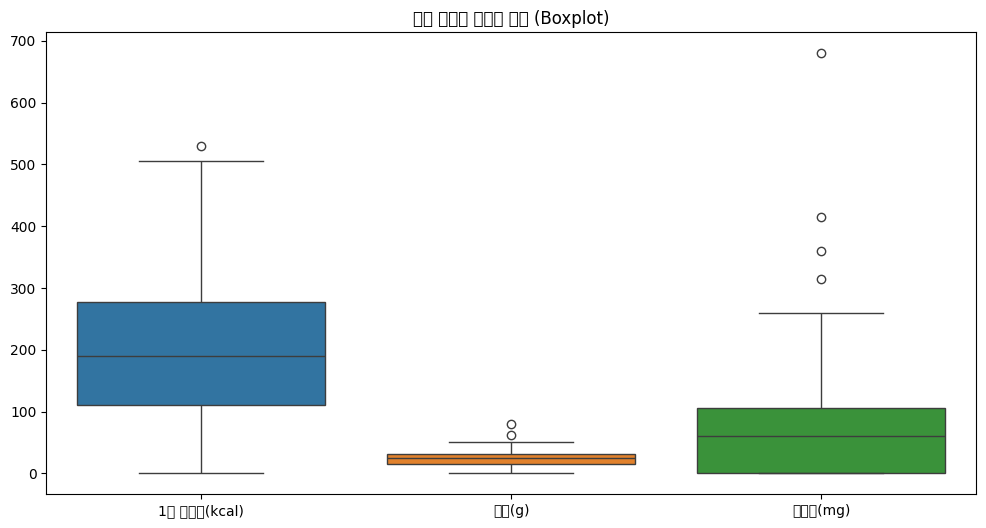

In [118]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=clean_menu[['1회 제공량(kcal)', '당류(g)', '카페인(mg)']])
plt.title("주요 영양소 이상치 확인 (Boxplot)")
plt.show()

6. 세그먼트 비교 (고카페인 vs 저카페인)

In [120]:
clean_menu['caffeine_group'] = np.where(clean_menu['카페인(mg)'] > 100, 'High', 'Low')
print(clean_menu.groupby('caffeine_group')['당류(g)'].mean())

caffeine_group
High    16.372549
Low     25.659722
Name: 당류(g), dtype: float64


### 확인 결과

1. 보통은 100에서 300 칼로리 사이의 음료들이 제일 많음

2. 고카페인 음료는 저카페인 음료보다 덜 달다

### 전처리 필요

1. menu 테이블에서는 음료 가격 정보가 보이지 않음
-> transcript의 amount와 연결?

2. 제품코드 말고 전부 str. 변환필요

3. Unnamed:0 제거

4. 결측치가 0으로 나오는데 0말고 다른 문자가 있나 확인하기

-> -가 들어가 있는 것 같아 보임


5. 제품명 중복 12건 나옴 확인 필요 (차이가 있긴함)

**커피, 티, 에이드, 이런식으로 카테고리를 나누는 것은 어떨까?**

# 분석 아이디어

### KPI

1. 총 고객 수 
2. 최종 쿠폰 전환율
3. 발생 매출
4. 객단가(총 결제 금액 / 결제 건 수) : 쿠폰을 쓴 사람과 안 쓴 사람의 객단가 차이 비교

### 대시보드 구성안
1. 쿠폰 유형별 최종 전환율
2. 연령대별 or 성별별 or 소득구간별 고객 분포도
3. 퍼널 이탈률 (received -> viewed -> completed)
4. 고객 소득과 누적 결제 금액 상관관계

소득이 높을 수록 스타벅스에서 돈을 많이 쓸까?